In [1]:
import itertools
from pathlib import Path
import yaml
import importlib

import numpy as np
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from elements.classes import ElementDataset

# Making a dataset from scratch

In [2]:
save_dir = Path("example_datasets")
save_dir.mkdir(exist_ok=True)

In [3]:
class_configs = [
    {"shape": None, "color": None, "texture": "solid"},
    {"shape": None, "color": "red", "texture": "solid"},
    {"shape": None, "color": "blue", "texture": "stripes_diagonal"},
    {"shape": None, "color": "green", "texture": "spots_polka"},
    {"shape": "circle", "color": None, "texture": "solid"},
    {"shape": "circle", "color": None, "texture": "spots_polka"},
    {"shape": "triangle", "color": "green", "texture": None},
    {"shape": "square", "color": "blue", "texture": None},
    {"shape": "triangle", "color": "red", "texture": "stripes_diagonal"},
    {"shape": "triangle", "color": "blue", "texture": "stripes_diagonal"},
    {"shape": "square", "color": "green", "texture": "spots_polka"},
    {"shape": "plus", "color": "magenta", "texture": "spots_polka"},
]

allowed_shapes = ['square', 'circle', 'triangle', 'plus']
allowed_colors = ['red', 'green', 'blue']
allowed_textures = ["solid", "spots_polka", "stripes_diagonal"]

allowed = {
    "shapes": allowed_shapes,
    "colors": allowed_colors,
    "textures": allowed_textures
}
dataset = ElementDataset(allowed, class_configs, 1000, 224, 4, 64, 16, 42, 123)

In [4]:
dataset.config

{'allowed': {'shapes': ['square', 'circle', 'triangle', 'plus'],
  'colors': ['red', 'green', 'blue'],
  'textures': ['solid', 'spots_polka', 'stripes_diagonal'],
  'sizes': (48, 80)},
 'class_configs': [{'shape': None, 'color': None, 'texture': 'solid'},
  {'shape': None, 'color': 'red', 'texture': 'solid'},
  {'shape': None, 'color': 'blue', 'texture': 'stripes_diagonal'},
  {'shape': None, 'color': 'green', 'texture': 'spots_polka'},
  {'shape': 'circle', 'color': None, 'texture': 'solid'},
  {'shape': 'circle', 'color': None, 'texture': 'spots_polka'},
  {'shape': 'triangle', 'color': 'green', 'texture': None},
  {'shape': 'square', 'color': 'blue', 'texture': None},
  {'shape': 'triangle', 'color': 'red', 'texture': 'stripes_diagonal'},
  {'shape': 'triangle', 'color': 'blue', 'texture': 'stripes_diagonal'},
  {'shape': 'square', 'color': 'green', 'texture': 'spots_polka'},
  {'shape': 'plus', 'color': 'magenta', 'texture': 'spots_polka'}],
 'n': 1000,
 'img_size': 224,
 'element_

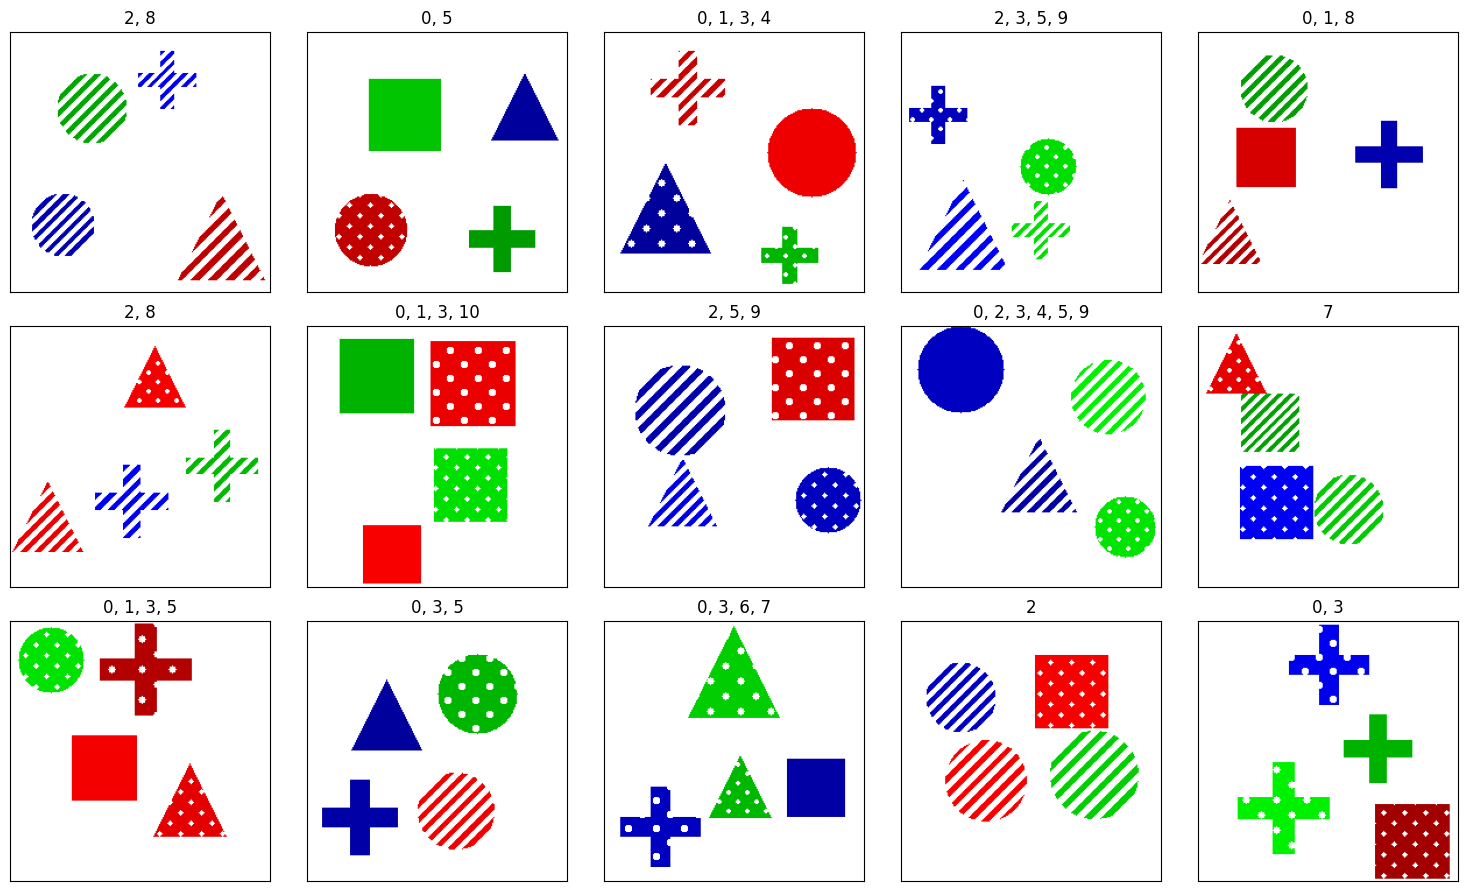

In [5]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()
for i, ax in enumerate(axes):
    img = dataset.get_item(i)
    classes = img.class_labels
    classes = [str(v) for v in classes]
    ax.imshow(img.img)
    ax.set_title(", ".join(classes))
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
#plt.savefig(save_dir / "simple_small.png")
plt.show()

In [6]:
dataloader = DataLoader(dataset, 32)
labels = []
for sample in dataloader:
    labels.append(sample[1])
labels = np.concatenate(labels)
print("No. imgs per class")
print(labels.sum(axis=0))
print("No. classes per image")
vals, counts = np.unique(labels.sum(axis=1), return_counts=True)
print(", ".join([f"{vals[i]: .0f}: {counts[i]}"for i in range(len(vals))]))

/Users/jazav7774/UiT/FYS-8603/elements/elements/classes.py:234: UserWarning: Not all elements could be placed without overlapping! Placing remaining 1 elements randomly.
  placed = False


No. imgs per class
[802. 386. 383. 384. 291. 298. 282. 302. 109. 108. 107.   0.]
No. classes per image
 0: 6,  1: 62,  2: 154,  3: 305,  4: 265,  5: 150,  6: 51,  7: 5,  8: 2


In [28]:
allowed_shapes = ['square', 'circle', 'triangle', 'plus']
allowed_colors = ['red', 'green', 'blue']
allowed_textures = ["solid", "spots_polka", "stripes_diagonal"]

In [34]:
class_configs = list(itertools.product(allowed_shapes, [None], allowed_textures))
print(len(class_configs))
class_configs = [v for v in class_configs if sum([in_v is None for in_v in v]) < 2]
print(len(class_configs))

12
12


In [35]:
class_configs = [{"shape": v[0], "color": v[1], "texture": v[2]} for v in class_configs]
class_configs

[{'shape': 'square', 'color': None, 'texture': 'solid'},
 {'shape': 'square', 'color': None, 'texture': 'spots_polka'},
 {'shape': 'square', 'color': None, 'texture': 'stripes_diagonal'},
 {'shape': 'circle', 'color': None, 'texture': 'solid'},
 {'shape': 'circle', 'color': None, 'texture': 'spots_polka'},
 {'shape': 'circle', 'color': None, 'texture': 'stripes_diagonal'},
 {'shape': 'triangle', 'color': None, 'texture': 'solid'},
 {'shape': 'triangle', 'color': None, 'texture': 'spots_polka'},
 {'shape': 'triangle', 'color': None, 'texture': 'stripes_diagonal'},
 {'shape': 'plus', 'color': None, 'texture': 'solid'},
 {'shape': 'plus', 'color': None, 'texture': 'spots_polka'},
 {'shape': 'plus', 'color': None, 'texture': 'stripes_diagonal'}]

In [46]:
allowed = {
    "shapes": allowed_shapes,
    "colors": allowed_colors,
    "textures": allowed_textures
}
dataset = ElementDataset(allowed, class_configs, 1000, 224, 1, 96, 24, 42, 123)

['square', 'circle', 'triangle', 'plus']

In [ ]:
dataset.config

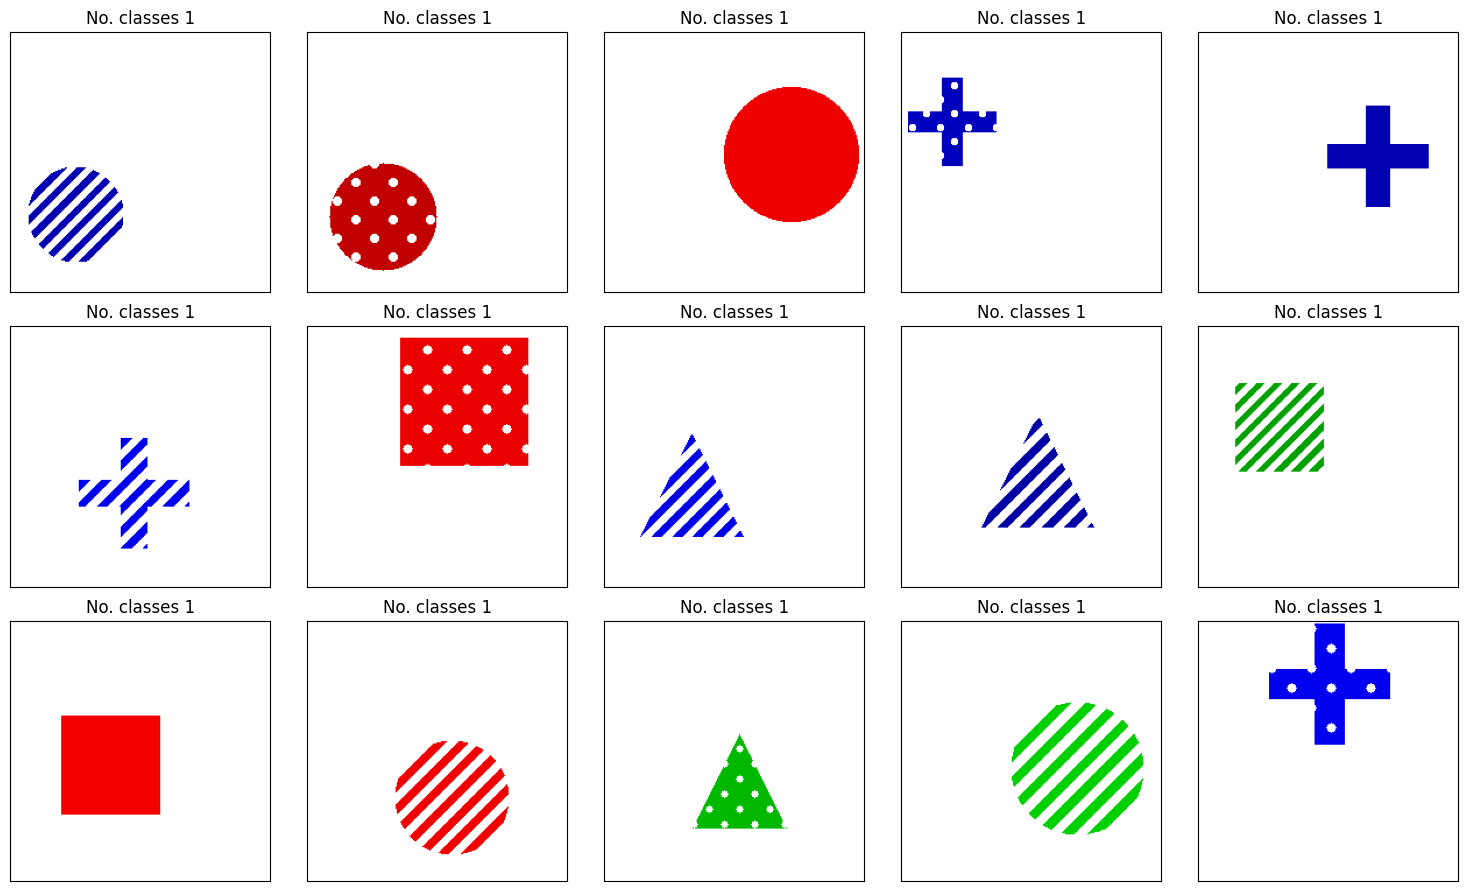

In [47]:
def plot_dataset(my_dataset, savefig=None, show_classes=False):
    fig, axes = plt.subplots(3, 5, figsize=(15, 9))
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        img, labels = my_dataset[i]
        classes = np.where(labels == 1)[0]
        ax.imshow(img.numpy().transpose(1, 2, 0))
        if show_classes:
            ax.set_title(f"No. classes {len(classes)}")
        ax.set_xticks([])
        ax.set_yticks([])
    plt.tight_layout()
    if savefig is not None:
        plt.savefig(savefig)
    plt.show()

plot_dataset(dataset, None, True)

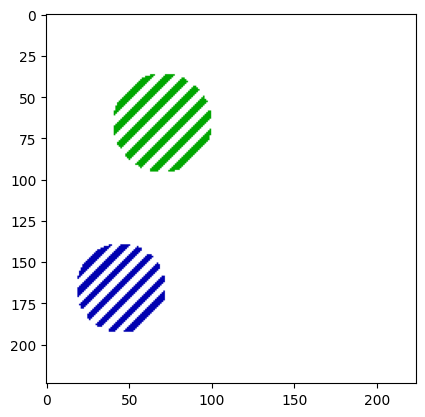

Classes for first image: [5]
Class configs for first image: [{'shape': 'circle', 'color': None, 'texture': 'stripes_diagonal'}]


In [44]:
plt.imshow(dataset[0][0].numpy().transpose(1, 2, 0))
plt.show()
print("Classes for first image:", np.where(dataset[0][1] == 1)[0])
print("Class configs for first image:", [dataset.config["class_configs"][i] for i in np.where(dataset[0][1] == 1)[0]])

In [45]:
dataloader = DataLoader(dataset, 32)
labels = []
for sample in dataloader:
    labels.append(sample[1])
labels = np.concatenate(labels)
print("No. imgs per class")
print(labels.sum(axis=0))
print("No. classes per image")
vals, counts = np.unique(labels.sum(axis=1), return_counts=True)
print(", ".join([f"{vals[i]: .0f}: {counts[i]}"for i in range(len(vals))]))

No. imgs per class
[163. 156. 163. 160. 176. 156. 155. 154. 166. 161. 149. 165.]
No. classes per image
 1: 76,  2: 924


# Create a dataset from a config file

In [ ]:
filename = Path("configs/simple_dataset.yaml")
with open(filename, "r") as fp:
    config = yaml.safe_load(fp)
config

In [ ]:
# This can be helpful if using lots of different datasets/classes
def get_obj_from_str(string, reload=False):
    module, cls = string.rsplit(".", 1)
    if reload:
        module_imp = importlib.import_module(module)
        importlib.reload(module_imp)
    return getattr(importlib.import_module(module, package=None), cls)

def instantiate_from_config(config):
    if not "target" in config:
        raise KeyError("Expected key `target` to instantiate.")
    return get_obj_from_str(config["target"])(**config.get("params", dict()))

dataset_creator = instantiate_from_config(config["dataset"])

In [ ]:
# But here's how to just do it
from elements.classes import ConceptElementDatasetCreator
dataset_creator =  ConceptElementDatasetCreator(**config["dataset"]["params"])

In [ ]:
# Class 013 is spotty squares
print(dataset_creator.class_configs[13])
class_dataset = dataset_creator("013")
plot_dataset(class_dataset)

In [ ]:
# Create images only containing a specific concept
concept_dataset = dataset_creator("red")
plot_dataset(concept_dataset)

In [ ]:
# Add spatial restrictions by using suffixes
concept_dataset = dataset_creator("red_top")
plot_dataset(concept_dataset)

In [ ]:
# Or just sample more images from the dataset config
random_dataset = dataset_creator("random500_12")
plot_dataset(random_dataset)

In [ ]:
# Once again, you can set spatial restrictions
random_dataset = dataset_creator("random500_12_left")
plot_dataset(random_dataset)

In [ ]:
filename = Path("configs/standard_dataset.yaml")
with open(filename, "r") as fp:
    config = yaml.safe_load(fp)
dataset_creator =  ConceptElementDatasetCreator(**config["dataset"]["params"])
dataset = dataset_creator("random500_0")
plot_dataset(dataset, show_classes=True)

In [ ]:
filename = Path("configs/simple_red_equals_triangle_dataset.yaml")
with open(filename, "r") as fp:
    config = yaml.safe_load(fp)
dataset_creator =  ConceptElementDatasetCreator(**config["dataset"]["params"])
dataset = dataset_creator("random500_0")
plot_dataset(dataset, show_classes=True)

In [ ]:
filename = Path("configs/simple_red_objects_are_triangles_dataset.yaml")
with open(filename, "r") as fp:
    config = yaml.safe_load(fp)
dataset_creator = ConceptElementDatasetCreator(**config["dataset"]["params"])
dataset = dataset_creator("random500_0")
plot_dataset(dataset, show_classes=True)